In [ ]:
import numpy as np
from sklearn.metrics import root_mean_squared_error, mean_absolute_error

from pybatteryid.simulation import simulate_model
from pybatteryid.utilities import load_model_from_file, invert_voltage_function
from pybatteryid.plotter import plot_time_vs_current, plot_time_vs_voltage

from pybatteryse.statespace import StateSpace
from pybatteryse.filters import ParticleFilter
from pybatteryse.plotter import plot_time_vs_soc
from pybatteryse.utilities import print_statespace_equations

from data import helper

### SOC estimation for NMC and LFP batteries using LTI and LPV models with PF

This example compares the SOC estimation performance for NMC and LFP batteries using LTI and LPV models with PF.

#### A. Load the test dataset

Load different datasets depending on the desired chemistry and temperature conditions.

In [2]:
# 'lfp' or 'nmc'
CHEMISTRY = 'lfp'
# 'cold' or 'hot'
TEMPERATURE_CONDITION = 'hot'
#
dataset = helper.load_npy_datasets(f'data/{CHEMISTRY}_soc_estimation/validation_{TEMPERATURE_CONDITION}.npy')
current_data_with_bad_sensor = np.load(f'data/{CHEMISTRY}_soc_estimation/validation_{TEMPERATURE_CONDITION}_automotivecurrent.npy', allow_pickle=True).item()
current_data_with_bad_sensor['current_values'] = current_data_with_bad_sensor['current_values'][:len(dataset['current_values'])]

bias = np.mean(current_data_with_bad_sensor['current_values'] - dataset['current_values'])
print(f"The actual bias in the bad current measurements is: {bias:3f} A.")

The actual bias in the bad current measurements is: -2.926709 A.


Here we specify that we wish to use bad current sensor values.

In [3]:
time_values = dataset['time_values'] / 3600
voltage_values = dataset['voltage_values']
temperature_values = dataset['temperature_values']
good_current_values = dataset['current_values']

Practically, we rarely know exact bias value, but we can roughly correct. Note that the actual bias value varies from dataset to dataset provided in the data folder. You can set the correction to various values to study how the filter behaviour changes for different biases.

In [4]:
# Adjust eta bounds according to bias
bias_correction = -bias
bad_current_values = current_data_with_bad_sensor['current_values'] + bias_correction

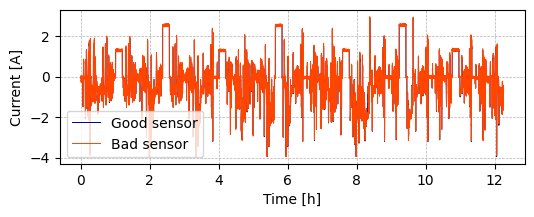

In [5]:
#
plot_time_vs_current([(time_values, good_current_values), (time_values, bad_current_values[:len(time_values)])],
                      units=('h', 'A'), colors=('darkblue', 'orangered'), legends=['Good sensor', 'Bad sensor'])

#### B. Load models

In [6]:
model_lti = load_model_from_file(f'data/{CHEMISTRY}_soc_estimation/model_lti_n=1.npy')
model_lpv = load_model_from_file(f'data/{CHEMISTRY}_soc_estimation/model_lpv_n,l=3,3.npy')

#### C. Simulate models

Here, we simulate models to give an idea about the accuracy of LTI and LPV models. Whenever, the accuracies of two models become comparable, the SOC estimation performance will also be quite similar.

In [7]:
initial_soc = invert_voltage_function(model_lti.emf_function,
                                      dataset['voltage_values'][0],
                                      dataset['temperature_values'][0])
#
current_profile = {'initial_soc': initial_soc,
                   'time_values': dataset['time_values'],
                   'current_values': dataset['current_values'],
                   'temperature_values': dataset['temperature_values'],
                   'voltage_values': dataset['voltage_values'][:3]}

In [8]:
voltage_simulated_lti = simulate_model(model_lti, current_profile)
voltage_simulated_lpv = simulate_model(model_lpv, current_profile)

LTI model with n = 1


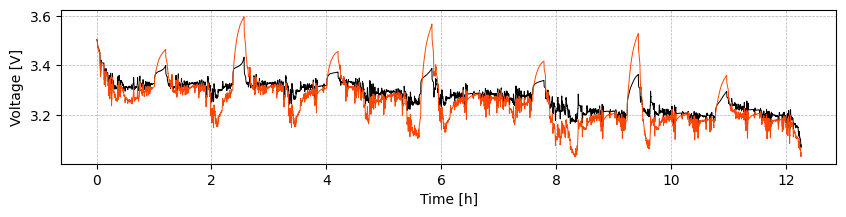

RMSE = 54.98 mV, MAE  = 41.85 mV

LPV model with n = 3


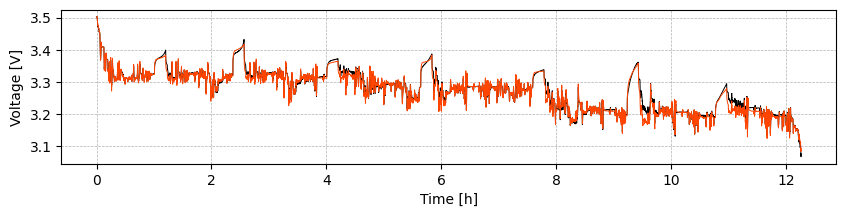

RMSE = 8.59 mV, MAE  = 5.15 mV



In [9]:
for label, model, voltage_simulated in [
    (f"LTI model with n = {model_lti.model_order}", model_lti, voltage_simulated_lti),
    (f"LPV model with n = {model_lpv.model_order}", model_lpv, voltage_simulated_lpv),
]:
    print(label)
    plot_time_vs_voltage(
        [(time_values, dataset['voltage_values']), (time_values, voltage_simulated)],
        units=('h', 'V'), colors=['k', 'orangered'], figsize=(10, 2)
    )
    rmse = root_mean_squared_error(
        voltage_simulated[:],
        dataset['voltage_values'][:]
    )
    mae = mean_absolute_error(
        voltage_simulated[:],
        dataset['voltage_values'][:]
    )
    print(f"RMSE = {rmse * 1e3:.2f} mV, "
          f"MAE  = {mae * 1e3:.2f} mV\n")

### Load state-space representation

In [10]:
ss_representation_lti = StateSpace(model_lti, state_components=['s', 'overpotentials'])
ss_representation_lpv = StateSpace(model_lpv, state_components=['s', 'overpotentials'])

In [11]:
print("For LTI model")
print_statespace_equations(ss_representation_lti)
#
print("For LPV model")
print_statespace_equations(ss_representation_lpv)

For LTI model


╭───────────── State-space equations ──────────────╮
│                                                  │
│ x_{k+1} = A(p_k) · x_k + B(p_k) · u_k            │
│ V_k     = EMF(s_k, T_k) + C · x_k + D(p_k) · u_k │
│                                                  │
│ where                                            │
│                                                  │
│ x_k = [s_k, x_1,k]   (dim = 2)                   │
│ p_k = [s_k, i_k, T_k]                            │
│ u_k = i_k                                        │
│                                                  │
│          ┌               ┐                       │
│          │ 1 ¦         0 │                       │
│ A(p_k) = │ --+---------- │                       │
│          │ 0 ¦ -a_1(p_k) │                       │
│          └               ┘                       │
│                                                  │
│          ┌                              ┐        │
│          │                       Δt / ℚ │        │
│ B(p_k) = │ ---------------------------- │        │
│          │ b_1(p_k) - a_1(p_k)·b_0(p_k) │        │
│          └                              ┘        │
│                                                  │
│     ┌       ┐                                    │
│ C = │ 0 ¦ 1 │                                    │
│     └       ┘                                    │
│                                                  │
│          ┌          ┐                            │
│ D(p_k) = │ b_0(p_k) │                            │
│          └          ┘                            │
╰──────────────────────────────────────────────────╯

For LPV model


╭───────────── State-space equations ──────────────╮
│                                                  │
│ x_{k+1} = A(p_k) · x_k + B(p_k) · u_k            │
│ V_k     = EMF(s_k, T_k) + C · x_k + D(p_k) · u_k │
│                                                  │
│ where                                            │
│                                                  │
│ x_k = [s_k, x_1,k, x_2,k, x_3,k]   (dim = 4)     │
│ p_k = [s_k, i_k, T_k]                            │
│ u_k = i_k                                        │
│                                                  │
│          ┌                     ┐                 │
│          │ 1 ¦         0  0  0 │                 │
│          │ --+---------------- │                 │
│ A(p_k) = │ 0 ¦ -a_1(p_k)  1  0 │                 │
│          │ 0 ¦ -a_2(p_k)  0  1 │                 │
│          │ 0 ¦ -a_3(p_k)  0  0 │                 │
│          └                     ┘                 │
│                                                  │
│          ┌                              ┐        │
│          │                       Δt / ℚ │        │
│          │ ---------------------------- │        │
│ B(p_k) = │ b_1(p_k) - a_1(p_k)·b_0(p_k) │        │
│          │ b_2(p_k) - a_2(p_k)·b_0(p_k) │        │
│          │ b_3(p_k) - a_3(p_k)·b_0(p_k) │        │
│          └                              ┘        │
│                                                  │
│     ┌             ┐                              │
│ C = │ 0 ¦ 1  0  0 │                              │
│     └             ┘                              │
│                                                  │
│          ┌          ┐                            │
│ D(p_k) = │ b_0(p_k) │                            │
│          └          ┘                            │
╰──────────────────────────────────────────────────╯

### Load PF and run it on the dataset

In [12]:
eta_bounds = (-4, 4)
variance_eta_y_e = 1e-3
# 
start_idx = 22000
# Dataset with bad current values
dataset_for_soc_estimation = {
    'current_values': bad_current_values[start_idx:],
    'voltage_values': voltage_values[start_idx:],
    'temperature_values': temperature_values[start_idx:],
}

In [13]:
#
pf = ParticleFilter(statespace=ss_representation_lti,
                    num_particles=20,
                    eta_bounds=eta_bounds,
                    variance_eta_y_e=variance_eta_y_e)
# Set initial conditions
state_estimates_lti, _ = pf.run(
    dataset=dataset_for_soc_estimation,
    initial_particles='auto'
)
soc_estimates_lti = state_estimates_lti[:, 0]

PF Progress: 100%|████████████████████████████████████████| 22140/22140 [00:09<00:00, 2335.80step/s]


In [14]:
pf = ParticleFilter(statespace=ss_representation_lpv,
                    num_particles=20,
                    eta_bounds=eta_bounds,
                    variance_eta_y_e=variance_eta_y_e)

# Set initial conditions
state_estimates_lpv, _ = pf.run(
    dataset=dataset_for_soc_estimation,
    initial_particles='auto'
)
soc_estimates_lpv = state_estimates_lpv[:, 0]

PF Progress: 100%|█████████████████████████████████████████| 22140/22140 [00:42<00:00, 523.04step/s]


In [15]:
# Coulomb counting method to calculate true SOC
soc_true = np.zeros(len(time_values))
# True initial SOC
soc_true[0] = invert_voltage_function(model_lti.emf_function, voltage_values[0])

for k in range(1, len(time_values)):
    soc_true[k] = soc_true[k - 1] + (good_current_values[k] * model_lti.sampling_period) / model_lti.battery_capacity

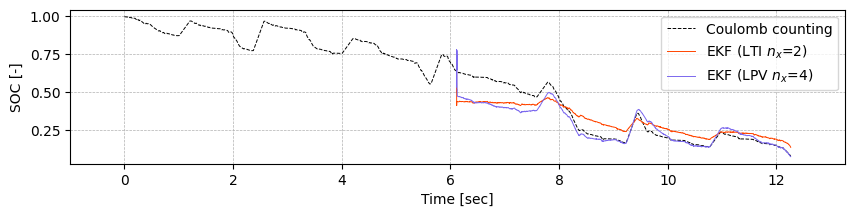

In [16]:
plot_time_vs_soc(
    [(time_values, soc_true),
     (time_values[start_idx:], soc_estimates_lti),
     (time_values[start_idx:], soc_estimates_lpv)
     ],
    colors=('k', 'orangered', 'mediumslateblue'),
    linestyles=['--'],
    legends=['Coulomb counting',
             f'EKF (LTI $n_x$={ss_representation_lti.state_dimension})',
             f'EKF (LPV $n_x$={ss_representation_lpv.state_dimension})'],
    figsize=(10, 2),
    xlims=(time_values[0] - 1, time_values[-1] + 1),
)

### Conclusions

For LFP batteries, PF does not necessarily outperform EKF. For NMC, however, PF can yield better SOC estimates under very large current sensor biases, owing to its non-Gaussian representation of the involved uncertainties. Therefore, the primary motivation for preferring PF over EKF is robustness to large current sensor biases, provided that SOC is sufficiently observable from voltage measurements.